# Bias Analysis

# Bias & Fairness Assessment  
### NovaCred Credit Applications Dataset (Cleaned)

This notebook evaluates **fairness risks in credit approvals** using the **cleaned dataset** produced by the Data Engineering pipeline (`01-data-quality.ipynb`).

We focus on patterns required in the project brief:
- **Gender disparate impact (DI)**
- **Age discrimination patterns**
- **ZIP code as a proxy feature**
- **Interaction effects (age × gender)**

**Important:** We intentionally do **not** use direct identifiers (name/email/SSN/IP) in any analysis.

## Setup

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

## Load cleaned dataset

We load the cleaned CSV created in `01-data-quality.ipynb`.  

In [42]:
DATA_PATH = "../data/cleaned_credit_applications.csv"
df = pd.read_csv(DATA_PATH)

df.shape

(500, 43)

In [43]:
df.head(3)

,_id,applicant_info_full_name,applicant_info_email,applicant_info_ssn,applicant_info_ip_address,applicant_info_gender,applicant_info_date_of_birth,applicant_info_zip_code,financials_annual_income,financials_credit_history_months,financials_debt_to_income,financials_savings_balance,decision_loan_approved,loan_purpose,decision_interest_rate,decision_approved_amount,age_years,spend_shopping,spend_rent,spend_alcohol,spend_dining,spend_healthcare,spend_fitness,spend_entertainment,spend_insurance,spend_travel,spend_transportation,spend_utilities,spend_groceries,spend_education,spend_adult_entertainment,spend_gambling,annual_income_missing,savings_balance_missing,debt_to_income_missing,savings_balance_zero,credit_history_suspicious,dob_missing,email_missing,ssn_missing,email_valid,ssn_duplicate,needs_review
0,app_200,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,Male,2001-03-09,10036.0,73000.0,23.0,0.20,31212.0,False,NaN,NaN,NaN,25.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,True,False,False
1,app_037,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,Male,1992-03-31,10032.0,78000.0,51.0,0.18,17915.0,False,NaN,NaN,NaN,33.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,True,False,False
2,app_215,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,Male,1989-10-24,10075.0,61000.0,41.0,0.21,37909.0,True,vacation,3.7,59000.0,36.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,True,False,False


## 3) Scope: exclude direct identifiers from analysis outputs

Privacy/pseudonymization is handled in `03-privacy-demo.ipynb`.  
Here we simply avoid using direct identifiers (name/email/SSN/IP) in fairness analysis.

In [44]:
pii_cols = [
    "applicant_info_full_name",
    "applicant_info_email",
    "applicant_info_ssn",
    "applicant_info_ip_address",
]

df_bias = df.drop(columns=[c for c in pii_cols if c in df.columns]).copy()
df_bias.shape

(500, 39)

## 4) Sanity checks

We report group counts for fairness-critical fields.  
This is essential for interpreting DI and subgroup comparisons.

In [45]:
summary = pd.Series({
    "n_rows": len(df_bias),
    "approval_rate_overall": df_bias["decision_loan_approved"].mean(),
    "n_unique_zip": df_bias["applicant_info_zip_code"].nunique(),
})
summary

n_rows                   500.000
approval_rate_overall      0.584
n_unique_zip             195.000
dtype: float64

In [46]:
df_bias["applicant_info_gender"].value_counts(dropna=False)

applicant_info_gender
Female    250
Male      247
NaN         3
Name: count, dtype: int64

## 6) Method: Disparate Impact (DI)

Selection rate for a group = mean(loan_approved)

We compute:
- **DI = ApprovalRate(Female) / ApprovalRate(Male)**

**Four-fifths rule (screening heuristic):**
- Flag potential adverse impact when **DI < 0.80** (not proof of discrimination).

### DI Helper Functions

In [71]:
def group_selection_rate(df_in: pd.DataFrame, outcome_col: str, group_col: str) -> pd.Series:
    return df_in.groupby(group_col)[outcome_col].mean()

def disparate_impact(df_in: pd.DataFrame, outcome_col: str, group_col: str, unpriv: str, priv: str) -> float:
    rates = group_selection_rate(df_in, outcome_col, group_col)
    return float(rates.loc[unpriv] / rates.loc[priv])

## 7) Issue 1: Gender Disparate Impact

We report:
- group counts (Female/Male)
- approval rates
- DI (Female/Male)
- four-fifths rule flag (DI < 0.80)

In [ ]:
df_gender = df_bias[df_bias["applicant_info_gender"].isin(["Female", "Male"])].copy()

gender_counts = df_gender["applicant_info_gender"].value_counts()
gender_rates = group_selection_rate(df_gender, "decision_loan_approved", "applicant_info_gender")
di_female_over_male = disparate_impact(df_gender, "decision_loan_approved", "applicant_info_gender", "Female", "Male")

di_flag = di_female_over_male < 0.80

print("Gender group sizes:")
print(gender_counts)
print()

print("Approval rates by gender:")
print(gender_rates)
print()

print(f"Disparate Impact (Female / Male): {di_female_over_male:.3f}")
print(f"Four-fifths rule triggered (DI < 0.80): {di_flag}")

Gender group sizes:
applicant_info_gender
Female    250
Male      247
Name: count, dtype: int64

Approval rates by gender:
applicant_info_gender
Female    0.508000
Male      0.659919
Name: decision_loan_approved, dtype: float64

Disparate Impact (Female / Male): 0.770
Four-fifths rule triggered (DI < 0.80): True


## Interpretation of Gender Disparity Results

The dataset includes **250 female applicants** and **247 male applicants**, so the gender distribution in the sample is relatively balanced.

However, the approval outcomes differ between the two groups. The approval rate for female applicants is **50.8%**, while the approval rate for male applicants is **65.9%**. This leads to a **Disparate Impact (DI) ratio of 0.77** when comparing female applicants to male applicants.

According to the **four-fifths rule**, a DI value below **0.80** may indicate potential adverse impact. Since the observed DI is **0.77**, the approval rate for female applicants is noticeably lower than for male applicants in this dataset.

This result does not by itself prove that the decision process is discriminatory. However, it does highlight a clear difference in outcomes between genders. To better understand this pattern, the following sections examine approval rates across **age groups**, possible **interaction effects**, and whether **other variables such as ZIP code may act as proxies** for protected characteristics.

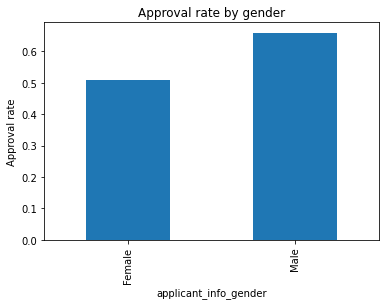

In [50]:
gender_rates.reindex(["Female", "Male"]).plot(kind="bar")
plt.ylabel("Approval rate")
plt.title("Approval rate by gender")
plt.show()

## Fairness metric cross-check

In addition to the disparate impact ratio, we compute demographic parity difference using Fairlearn. This measures the absolute gap in selection rates between groups and complements the ratio-based DI measure.

In [74]:
from fairlearn.metrics import demographic_parity_difference

y = df_gender["decision_loan_approved"].astype(int)
s = df_gender["applicant_info_gender"]

# We use observed approval decisions as the outcome under review.
dp_diff = demographic_parity_difference(
    y_true=y,
    y_pred=y,
    sensitive_features=s
)

print(f"Demographic parity difference: {dp_diff:.3f}")

Demographic parity difference: 0.152


## 8) Issue 2: Age-based patterns

We bucket ages and compare approval rates across age buckets.

In [65]:
df_bias["age_years"] = pd.to_numeric(df_bias["age_years"], errors="coerce")
df_bias["age_years"].describe()

count    495.000000
mean      41.232929
std       10.944332
min       23.400000
25%       32.400000
50%       39.500000
75%       47.550000
max       67.400000
Name: age_years, dtype: float64

In [66]:
bins = [18, 25, 35, 45, 55, 65, 200]
labels = ["18-24", "25-34", "35-44", "45-54", "55-64", "65+"]

df_age = df_bias.copy()
df_age["age_bucket"] = pd.cut(df_age["age_years"], bins=bins, labels=labels, right=False)

age_counts = df_age["age_bucket"].value_counts().sort_index()
age_rates = df_age.groupby("age_bucket")["decision_loan_approved"].mean().sort_index()

age_counts, age_rates

/var/folders/cb/178szk3j0w7_ptppcgsj5yk00000gn/T/ipykernel_5432/4000937539.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_rates = df_age.groupby("age_bucket")["decision_loan_approved"].mean().sort_index()


(age_bucket
 18-24     11
 25-34    149
 35-44    174
 45-54     92
 55-64     56
 65+       13
 Name: count, dtype: int64,
 age_bucket
 18-24    0.545455
 25-34    0.442953
 35-44    0.672414
 45-54    0.630435
 55-64    0.625000
 65+      0.538462
 Name: decision_loan_approved, dtype: float64)

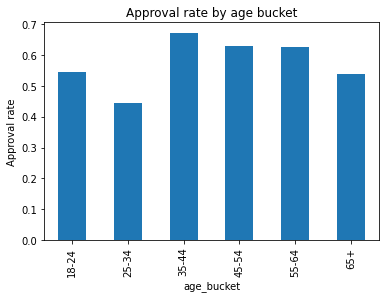

In [64]:
ax = age_rates.plot(kind="bar")
ax.set_ylabel("Approval rate")
ax.set_title("Approval rate by age bucket")
plt.show()

## Interpretation of Approval Rates by Age Group

The approval rates are not the same across age groups, which suggests that age may be related to loan decisions in this dataset.

The **25–34** group has the lowest approval rate at around **44.3%**, while the **35–44** group has the highest at about **67.2%**. Applicants in the **45–54** and **55–64** groups also have relatively high approval rates, both above **62%**. In contrast, the **18–24** and **65+** groups are closer to the middle, with approval rates around **54%**.

This pattern suggests that applicants in the middle age ranges tend to receive approvals more often than younger applicants and those in the 25–34 group in particular. At the same time, the smallest groups in the data are **18–24** and **65+**, so those results should be interpreted with a bit more caution because they are based on fewer observations.

Overall, the results show that approval outcomes vary across age groups, which makes age an important factor to examine further. The next step is to check whether these patterns also differ by **gender within age groups**, since interaction effects can reveal disparities that are not visible when each variable is looked at separately.

## 9) Interaction effects (age × gender)

To go beyond overall DI, we test whether approval gaps differ across **age buckets** (interaction effect).

In [54]:
df_age_gender = df_age[df_age["applicant_info_gender"].isin(["Female", "Male"])].copy()

age_gender_rates = (
    df_age_gender
    .groupby(["age_bucket", "applicant_info_gender"])["decision_loan_approved"]
    .mean()
    .unstack()
    .reindex(columns=["Female", "Male"])
)

age_gender_rates

/var/folders/cb/178szk3j0w7_ptppcgsj5yk00000gn/T/ipykernel_5432/794387973.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_age_gender


applicant_info_gender,Female,Male
age_bucket,,
18-24,0.500000,0.600000
25-34,0.333333,0.563380
35-44,0.621951,0.717391
45-54,0.581395,0.666667
55-64,0.548387,0.720000
65+,0.500000,0.600000


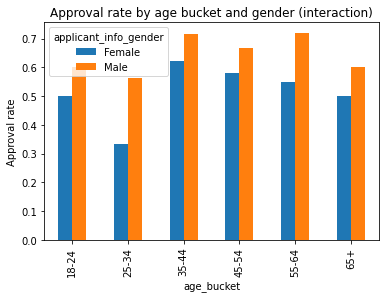

In [55]:
ax = age_gender_rates.plot(kind="bar")
ax.set_ylabel("Approval rate")
ax.set_title("Approval rate by age bucket and gender (interaction)")
plt.show()

## Interpretation of Interaction Effects Between Age and Gender

Looking at age and gender together gives a clearer picture than looking at each variable separately. Across all age groups in the table, **male applicants have a higher approval rate than female applicants**, which suggests that the gender gap is not limited to just one part of the dataset.

The gap is especially noticeable in the **25–34** group, where the approval rate is about **33.3% for female applicants** compared with **56.3% for male applicants**. A clear difference also appears in the **55–64** group, where female applicants have an approval rate of about **54.8%** and male applicants about **72.0%**. In the other age groups, the same pattern remains, even if the size of the gap is smaller.

This matters because it shows that the overall gender disparity is not being driven by only one age category. Instead, the lower approval rate for female applicants appears quite consistently across the age buckets shown here. That makes the pattern more concerning, since it suggests the disparity is broad rather than isolated.

At the same time, some age groups contain fewer observations than others, so the exact rates in the smallest groups should be interpreted with some caution. Even so, the interaction analysis strengthens the earlier result by showing that differences in approval outcomes remain visible when gender is examined within age groups.

## 10) Proxy discrimination analysis (ZIP code)

ZIP code is not a protected attribute, but it can act as a **proxy** for protected characteristics or socioeconomic factors.
We check proxy risk by:
- summarizing approval rates by ZIP (top ZIPs by volume)
- checking whether gender composition differs by ZIP (female_share)

In [56]:
top_n = 10
top_zips = df_bias["applicant_info_zip_code"].value_counts().head(top_n).index

df_zip = df_bias[df_bias["applicant_info_zip_code"].isin(top_zips)].copy()

zip_summary = (
    df_zip
    .groupby("applicant_info_zip_code")
    .agg(
        n=("decision_loan_approved", "size"),
        approval_rate=("decision_loan_approved", "mean"),
        female_share=("applicant_info_gender", lambda s: (s == "Female").mean()),
        avg_age=("age_years", "mean"),
    )
    .sort_values("n", ascending=False)
)

zip_summary

,n,approval_rate,female_share,avg_age
applicant_info_zip_code,,,,
10048.0,8,0.750000,0.125000,39.425000
10096.0,7,0.285714,0.142857,35.442857
90284.0,7,0.428571,1.000000,46.128571
10004.0,6,1.000000,0.000000,43.866667
10019.0,6,0.333333,0.166667,40.500000
10020.0,6,0.666667,0.000000,40.966667
10057.0,6,0.500000,0.000000,43.733333
10002.0,5,0.600000,0.000000,43.720000
90218.0,5,0.800000,0.800000,37.320000


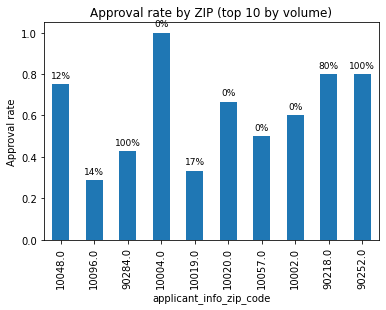

In [57]:
# ax = zip_summary["approval_rate"].plot(kind="bar")
# ax.set_ylabel("Approval rate")
# ax.set_title(f"Approval rate by ZIP (top {top_n} by volume)")
# plt.show()
ax = zip_summary["approval_rate"].plot(kind="bar")
ax.set_ylabel("Approval rate")
ax.set_title(f"Approval rate by ZIP (top {top_n} by volume)")

# Add female_share labels on top of bars
for i, (zip_code, row) in enumerate(zip_summary.iterrows()):
    approval = row["approval_rate"]
    female_share = row["female_share"]
    ax.text(
        i,                          # bar index
        approval + 0.02,            # a bit above the bar
        f"{female_share:.0%}",      # format as percent
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.ylim(0, min(1.05, zip_summary["approval_rate"].max() + 0.15))
plt.show()

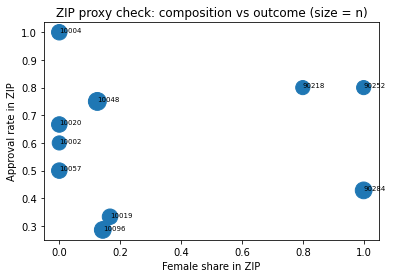

In [58]:
import matplotlib.pyplot as plt

tmp = zip_summary.reset_index().rename(columns={"applicant_info_zip_code": "zip_code"})

plt.figure()
plt.scatter(tmp["female_share"], tmp["approval_rate"], s=tmp["n"]*40)
plt.xlabel("Female share in ZIP")
plt.ylabel("Approval rate in ZIP")
plt.title("ZIP proxy check: composition vs outcome (size = n)")
for _, r in tmp.iterrows():
    plt.text(r["female_share"], r["approval_rate"], str(int(r["zip_code"])), fontsize=7)

plt.show()

### Interpretation: ZIP proxy check (female share vs approval rate)

This scatter plot compares, for the most frequent ZIP codes:
- **x-axis:** female share within the ZIP (composition)
- **y-axis:** approval rate within the ZIP (outcome)
- **point size:** number of applications in that ZIP (n)

**What we see:**  
The points are not arranged along a clear upward or downward trend. Instead, ZIPs with similar female shares can have very different approval rates (e.g., low-female-share ZIPs range from low to high approval), and ZIPs with high female share also show mixed approval outcomes. This lack of a consistent  pattern suggests that within this top-ZIP subset, **female composition alone does not strongly explain ZIP-level approval differences**.

**How to interpret for “proxy risk”:**  
- The plot does **not** provide strong evidence that higher female share systematically drives lower (or higher) approvals via ZIP in this subset.  
- However, we still observe meaningful **outcome variation across ZIPs**, and sample sizes per ZIP are small (n≈5–8), so this remains a **screening indicator** rather than a definitive conclusion.

**Governance implication:**  
ZIP should be treated as a **potential proxy feature** and monitored (e.g., periodic subgroup outcome checks and feature justification). Stronger conclusions would require larger per-ZIP samples or controlled analysis (e.g., adding ZIP as a control in a model to see whether gender disparities shrink).

In [59]:
zip_corr = zip_summary[["approval_rate", "female_share"]].corr().iloc[0, 1]
zip_corr

0.07318756749963203

## 11) Correlation scan (numeric fields vs approval outcome)

We analyze correlations between fields and outcomes.
We restrict this scan to numeric columns and interpret correlations as screening signals (not causality).

In [60]:
df_num = df_bias.select_dtypes(include=[np.number]).copy()
df_num["decision_loan_approved"] = df_bias["decision_loan_approved"].astype(int)

corr = df_num.corr(numeric_only=True)["decision_loan_approved"].sort_values(ascending=False)
corr

decision_loan_approved              1.000000
financials_annual_income            0.178610
financials_credit_history_months    0.140888
financials_savings_balance          0.133481
age_years                           0.123885
financials_debt_to_income          -0.007757
applicant_info_zip_code            -0.123682
decision_interest_rate                   NaN
decision_approved_amount                 NaN
spend_shopping                           NaN
spend_rent                               NaN
spend_alcohol                            NaN
spend_dining                             NaN
spend_healthcare                         NaN
spend_fitness                            NaN
spend_entertainment                      NaN
spend_insurance                          NaN
spend_travel                             NaN
spend_transportation                     NaN
spend_utilities                          NaN
spend_groceries                          NaN
spend_education                          NaN
spend_adul

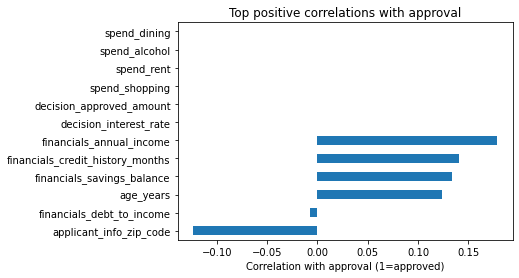

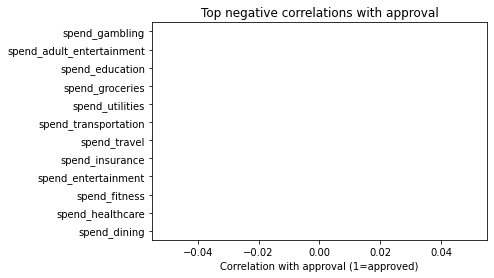

In [61]:
top_k = 12
corr_no_self = corr.drop("decision_loan_approved", errors="ignore")

ax = corr_no_self.head(top_k).sort_values().plot(kind="barh")
ax.set_xlabel("Correlation with approval (1=approved)")
ax.set_title("Top positive correlations with approval")
plt.show()

ax = corr_no_self.tail(top_k).sort_values().plot(kind="barh")
ax.set_xlabel("Correlation with approval (1=approved)")
ax.set_title("Top negative correlations with approval")
plt.show()

/Users/oleeiane/opt/anaconda3/lib/python3.9/site-packages/seaborn/matrix.py:256: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


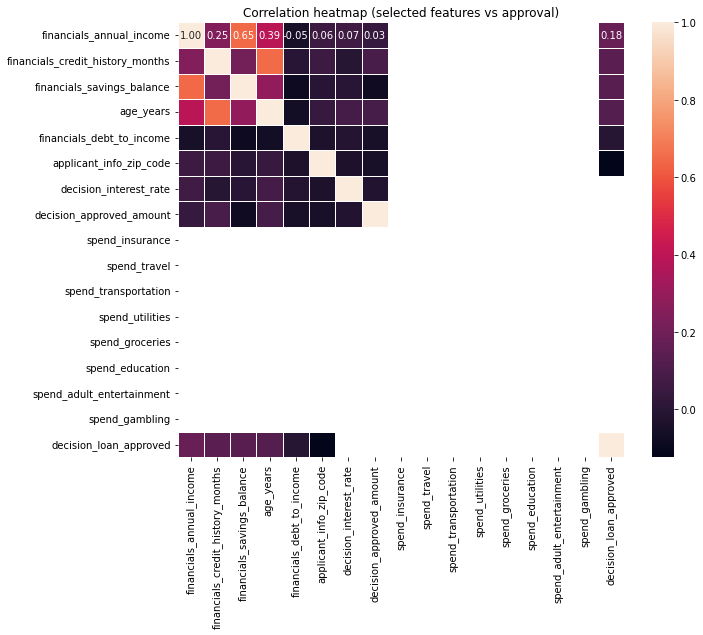

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Numeric columns only (exclude IDs if any sneak in)
df_num = df_bias.select_dtypes(include=[np.number]).copy()

# Ensure outcome is numeric for correlations
df_num["decision_loan_approved"] = df_bias["decision_loan_approved"].astype(int)

# Pick top-k most correlated with outcome (+ and -), then plot those together
corr_all = df_num.corr(numeric_only=True)["decision_loan_approved"].sort_values(ascending=False)
corr_no_self = corr_all.drop("decision_loan_approved", errors="ignore")

top_k = 8
selected = list(corr_no_self.head(top_k).index) + list(corr_no_self.tail(top_k).index) + ["decision_loan_approved"]
corr_sel = df_num[selected].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_sel, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation heatmap (selected features vs approval)")
plt.show()